# Road Sign Recognition Model: Train, Validate and Test

This notebook provides a comprehensive workflow for training, validating, and testing a road sign recognition model using the German Traffic Sign Recognition Benchmark (GTSRB) dataset.

## 1. Setup and Imports

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sys.path.append('../')
from src.model import RoadSignRecognitionModel, preprocess_image

/Users/bogdan/Desktop/Subjects WUT/Season 6/AI Fundamentals/road-sign-recognition/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 2. Data Loading and Exploration

In [4]:
# Load the training and test data
train_csv_path = '../data/raw/Train.csv'
test_csv_path = '../data/raw/Test.csv'
train_images_dir = '../data/raw/'
test_images_dir = '../data/raw/'

# Load the CSV files
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

# Display information about the datasets
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nTraining data sample:")
print(train_df.head())

Training data shape: (39209, 8)
Test data shape: (12630, 8)

Training data sample:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


Number of classes: 43


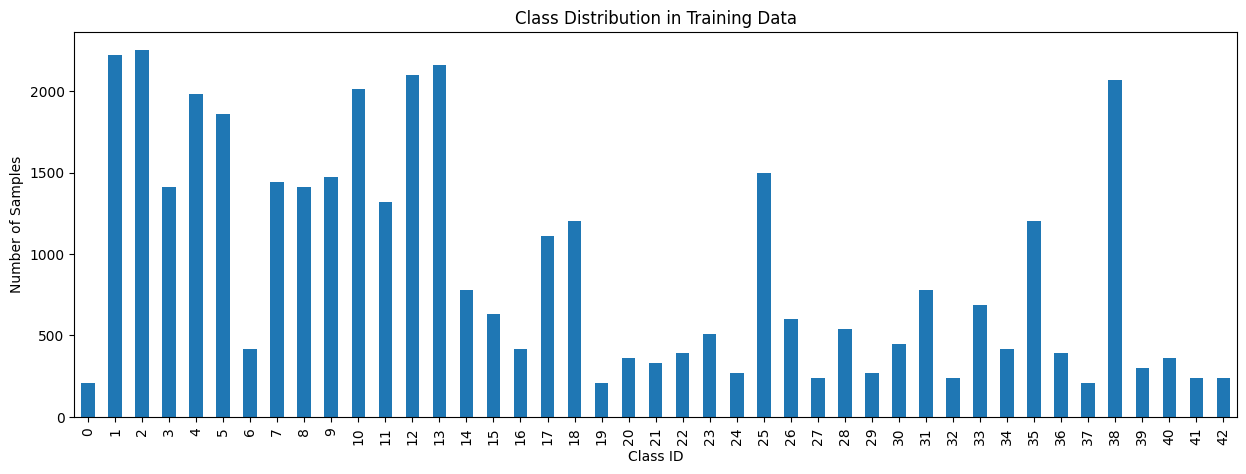

In [5]:
# Check class distribution in training data
class_distribution = train_df['ClassId'].value_counts().sort_index()
num_classes = len(class_distribution)
print(f"Number of classes: {num_classes}")

plt.figure(figsize=(15, 5))
class_distribution.plot(kind='bar')
plt.title('Class Distribution in Training Data')
plt.xlabel('Class ID')
plt.ylabel('Number of Samples')
plt.show()

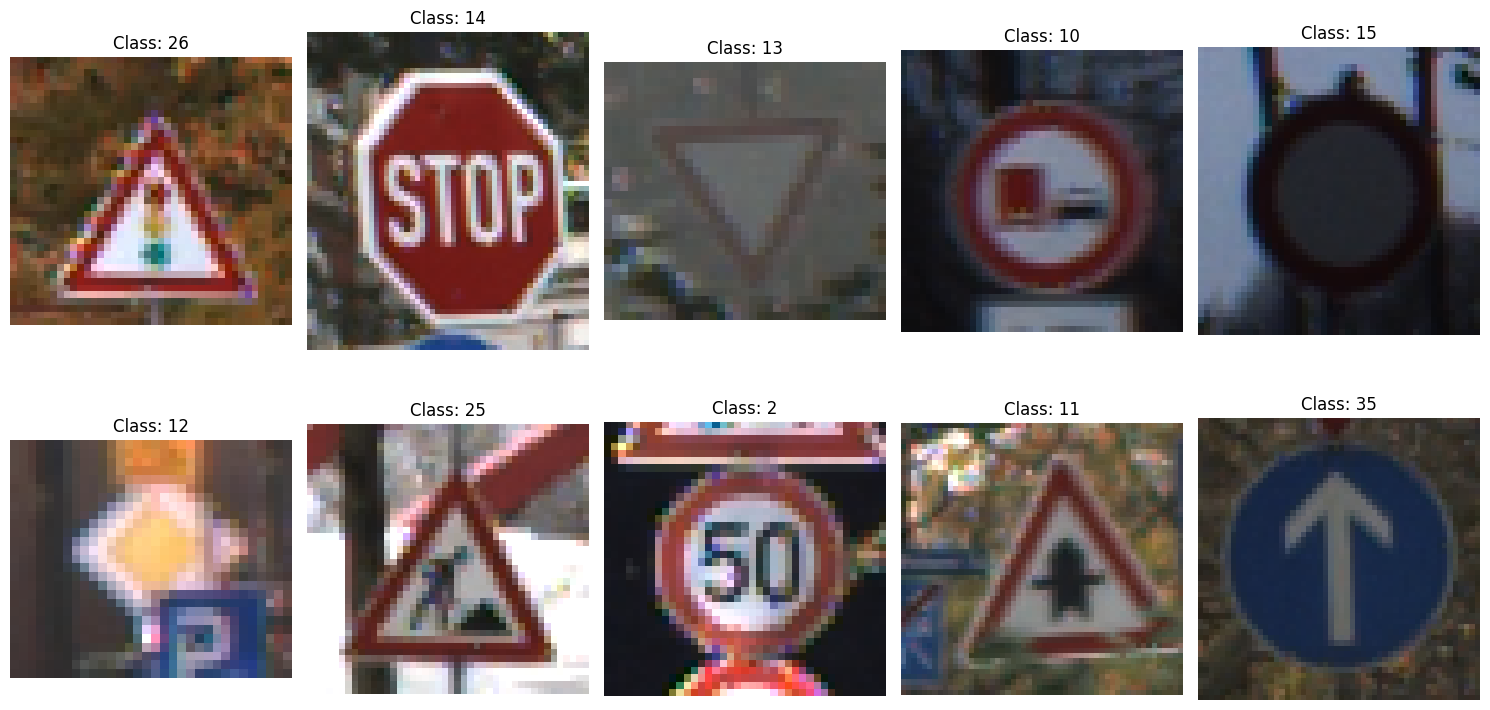

In [6]:
# Display some sample images
def show_sample_images(df, images_dir, num_samples=10):
    plt.figure(figsize=(15, 8))
    samples = df.sample(num_samples)
    count = 0
    
    for _, row in samples.iterrows():
        if count >= num_samples:
            break
            
        img_path = os.path.join(images_dir, row['Path'])
        img = cv2.imread(img_path)
        
        # Check if image was loaded successfully
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(2, 5, count+1)
            plt.imshow(img)
            plt.title(f"Class: {row['ClassId']}")
            plt.axis('off')
            count += 1
        else:
            print(f"Warning: Could not load image at {img_path}")
    
    plt.tight_layout()
    plt.show()

# Check if the Train directory exists
if os.path.exists(train_images_dir):
    show_sample_images(train_df, train_images_dir)
else:
    print(f"Error: Training images directory not found at {train_images_dir}")
    print("Please check the path and make sure the GTSRB dataset is properly extracted.")

## 3. Data Preprocessing

In [7]:
def load_and_preprocess_data(df, images_dir, target_size=(32, 32)):
    """
    Load images from paths in dataframe and preprocess them
    """
    X = []
    y = []
    
    for _, row in df.iterrows():
        img_path = os.path.join(images_dir, row['Path'])
        if os.path.exists(img_path):
            # Load and preprocess image
            img = cv2.imread(img_path)
            if img is not None:
                try:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
                    img = cv2.resize(img, target_size)  # Resize to target size
                    img = img / 255.0  # Normalize pixel values
                    
                    X.append(img)
                    y.append(row['ClassId'])
                except Exception as e:
                    print(f"Error processing image {img_path}: {e}")
            else:
                print(f"Could not load image: {img_path}")
    
    if not X:
        raise ValueError("No images could be loaded. Please check your data paths.")
    
    return np.array(X), np.array(y)

In [8]:
# Load a subset of the data for faster development (comment this out to use all data)
# sample_size = 10000
# train_df_subset = train_df.sample(min(sample_size, len(train_df)), random_state=42)

# Uncomment the following line to use all data
train_df_subset = train_df

print(f"Using {len(train_df_subset)} out of {len(train_df)} training samples")

Using 39209 out of 39209 training samples


In [9]:
# Load and preprocess the training data
print("Loading and preprocessing training data...")
X_train_full, y_train_full = load_and_preprocess_data(train_df_subset, train_images_dir)
print(f"Training data loaded: {X_train_full.shape}, {y_train_full.shape}")

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")

Loading and preprocessing training data...
Training data loaded: (39209, 32, 32, 3), (39209,)
Training set: (31367, 32, 32, 3), (31367,)
Validation set: (7842, 32, 32, 3), (7842,)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.3020105..2.477668].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.447609..25.861246].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.281199..4.1462727].


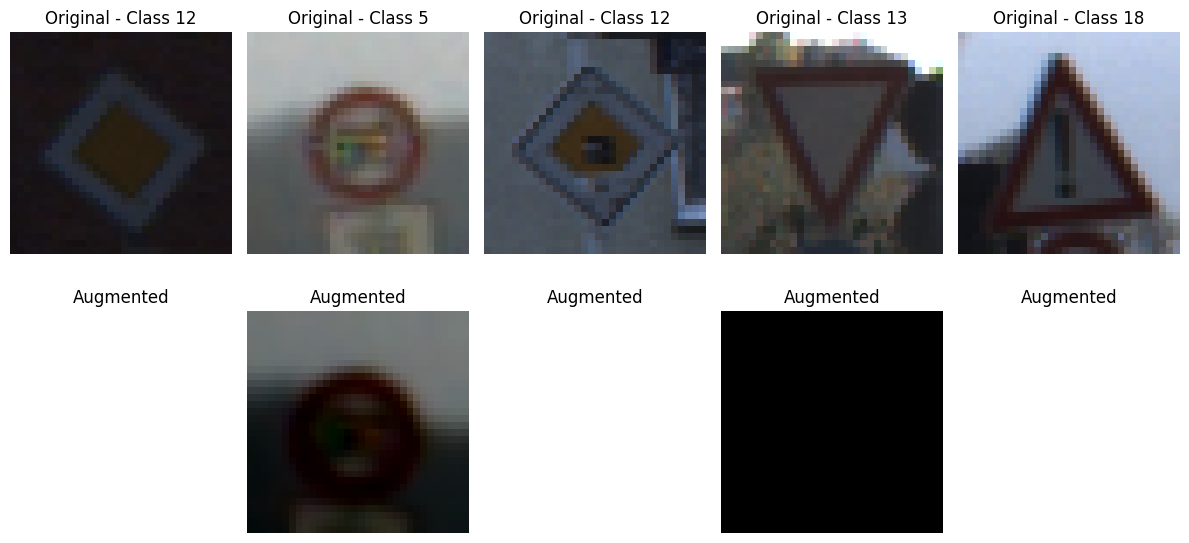

In [11]:
# Data augmentation (optional but recommended)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

# Visualize data augmentation effect
plt.figure(figsize=(12, 6))
for i in range(5):
    img = X_train[i]
    augmented_img = data_augmentation(tf.expand_dims(img, 0))[0]
    
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"Original - Class {y_train[i]}")
    plt.axis('off')
    
    plt.subplot(2, 5, i+6)
    plt.imshow(augmented_img)
    plt.title("Augmented")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Model Definition and Training

In [12]:
# Initialize the model
input_shape = X_train.shape[1:]
print(f"Input shape: {input_shape}")

# Create model
model = RoadSignRecognitionModel(input_shape=input_shape, num_classes=num_classes)

# Display model summary
model.model.summary()

Input shape: (32, 32, 3)


/Users/bogdan/Desktop/Subjects WUT/Season 6/AI Fundamentals/road-sign-recognition/venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,459 (642.42 KB)

 Trainable params: 164,459 (642.42 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Set up callbacks
checkpoint_path = "../models/road_sign_model_checkpoint.h5"
checkpoint = ModelCheckpoint(
    checkpoint_path, 
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

callbacks = [checkpoint, early_stopping]

In [14]:
# Train the model
epochs = 15
batch_size = 32

history = model.train(
    X_train, y_train,
    x_val=X_val, y_val=y_val,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.2959 - loss: 2.6114 - val_accuracy: 0.9285 - val_loss: 0.3099
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8695 - loss: 0.4249 - val_accuracy: 0.9769 - val_loss: 0.0978
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9369 - loss: 0.2022 - val_accuracy: 0.9850 - val_loss: 0.0600
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9594 - loss: 0.1350 - val_accuracy: 0.9818 - val_loss: 0.0670
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9672 - loss: 0.1047 - val_accuracy: 0.9904 - val_loss: 0.0382
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9759 - loss: 0.0782 - val_accuracy: 0.9867 - val_loss: 0.0490
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9793 - loss: 0.0738 - val_accuracy: 0.9913 - val_loss: 0.0334
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9847 - loss: 0.0498 - 

In [15]:
# Optionally, create and train a model with data augmentation
def train_with_augmentation():
    # Create a new model for augmentation
    aug_model = RoadSignRecognitionModel(input_shape=input_shape, num_classes=num_classes)
    
    # Create data augmentation preprocessing layers
    inputs = tf.keras.Input(shape=input_shape)
    augmented = data_augmentation(inputs)
    outputs = aug_model.model(augmented)
    
    # Create a new model with augmentation included
    model_with_aug = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model_with_aug.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train the model with augmentation
    aug_history = model_with_aug.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks
    )
    
    return aug_model, aug_history

# Uncomment to train with augmentation
# print("Training with data augmentation...")
# aug_model, aug_history = train_with_augmentation()

## 5. Evaluate Training Results

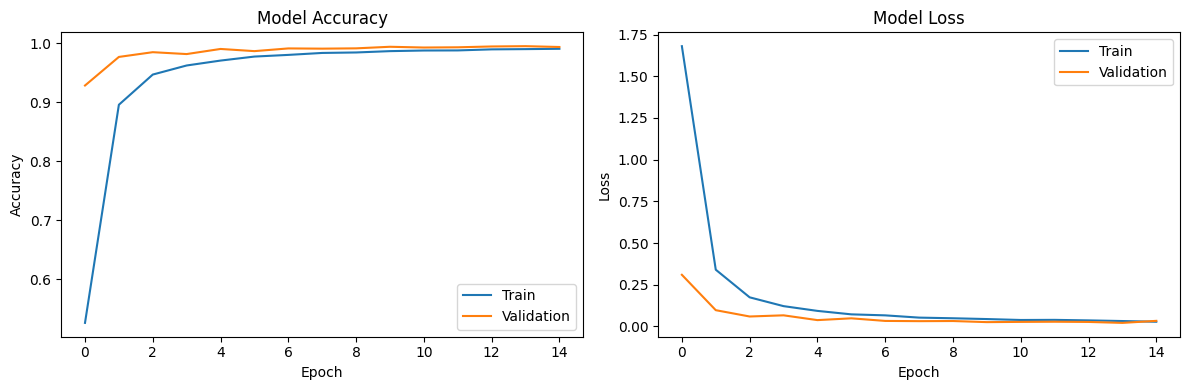

In [15]:
# Plot training history
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 6. Test Set Evaluation

In [17]:
# Load and preprocess a subset of test data
test_sample_size = 2000000000000000000000000000000000
test_df_subset = test_df.sample(min(test_sample_size, len(test_df)), random_state=42)

print("Loading and preprocessing test data...")
X_test, y_test = load_and_preprocess_data(test_df_subset, test_images_dir)
print(f"Test data loaded: {X_test.shape}, {y_test.shape}")

Loading and preprocessing test data...
Test data loaded: (12630, 32, 32, 3), (12630,)


In [18]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9680 - loss: 0.1915
Test accuracy: 0.9645, Test loss: 0.2195


In [19]:
# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.98      0.99      0.98       720
           2       0.96      0.99      0.98       750
           3       0.99      0.94      0.96       450
           4       0.99      0.98      0.98       660
           5       0.93      0.95      0.94       630
           6       0.99      0.81      0.89       150
           7       0.99      0.96      0.97       450
           8       0.97      0.96      0.97       450
           9       0.96      1.00      0.98       480
          10       1.00      0.98      0.99       660
          11       0.93      0.99      0.96       420
          12       0.95      0.96      0.95       690
          13       0.99      0.98      0.98       720
          14       0.98      1.00      0.99       270
          15       0.94      1.00      0.97       210
          16     

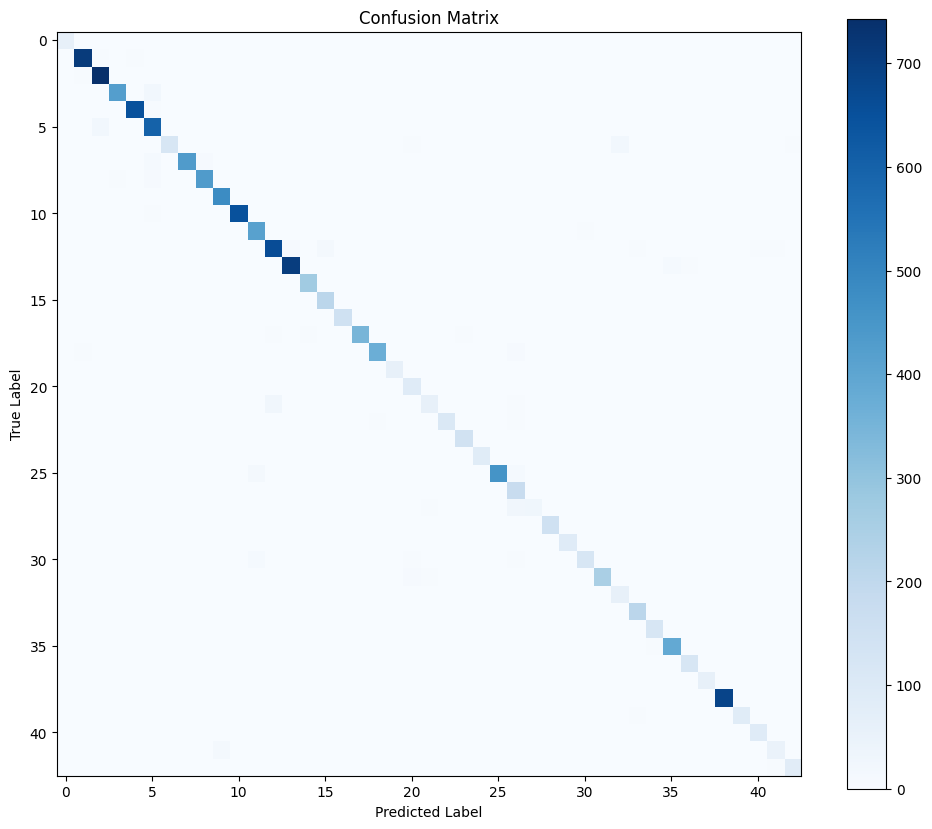

In [20]:
# Confusion matrix visualization
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    
    # Add axis labels
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Create a list of class indices 
classes = np.arange(num_classes)

plot_confusion_matrix(y_test, y_pred, classes)

## 7. Visualize Model Predictions

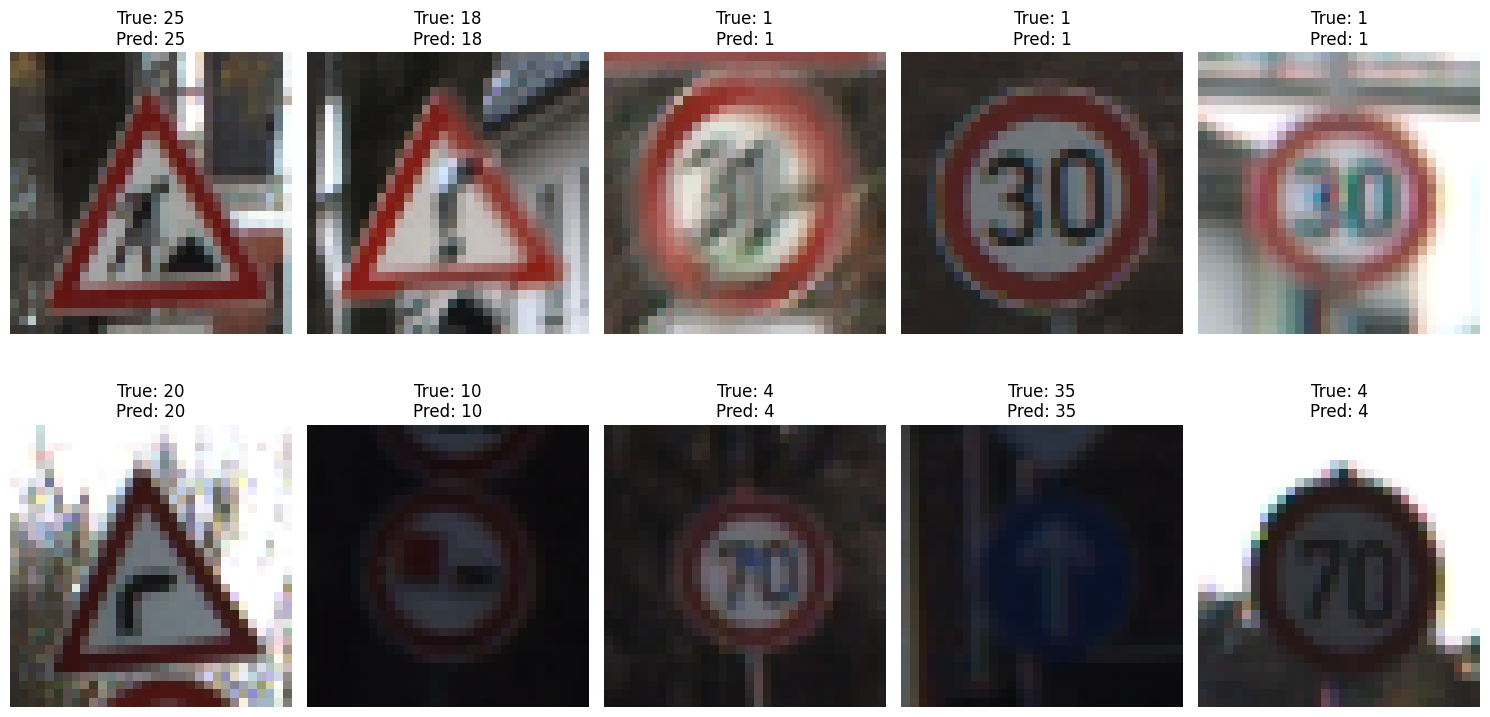

In [21]:
# Visualize some predictions
def visualize_predictions(X, y_true, y_pred, num_samples=10):
    # Randomly select samples
    indices = np.random.choice(range(len(X)), num_samples, replace=False)
    
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i+1)
        plt.imshow(X[idx])
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis('off')
        
        # Highlight wrong predictions in red
        if y_true[idx] != y_pred[idx]:
            plt.gca().spines['bottom'].set_color('red')
            plt.gca().spines['top'].set_color('red')
            plt.gca().spines['left'].set_color('red')
            plt.gca().spines['right'].set_color('red')
            plt.gca().spines['bottom'].set_linewidth(5)
            plt.gca().spines['top'].set_linewidth(5)
            plt.gca().spines['left'].set_linewidth(5)
            plt.gca().spines['right'].set_linewidth(5)
    
    plt.tight_layout()
    plt.show()

visualize_predictions(X_test, y_test, y_pred)

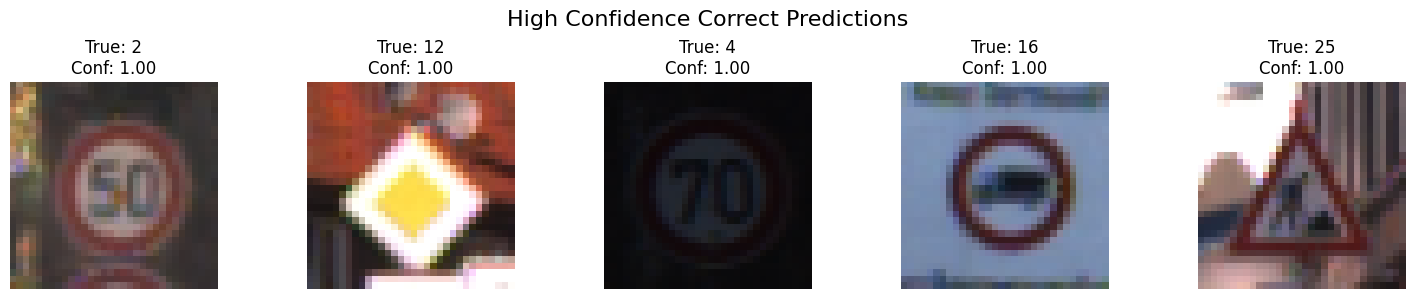

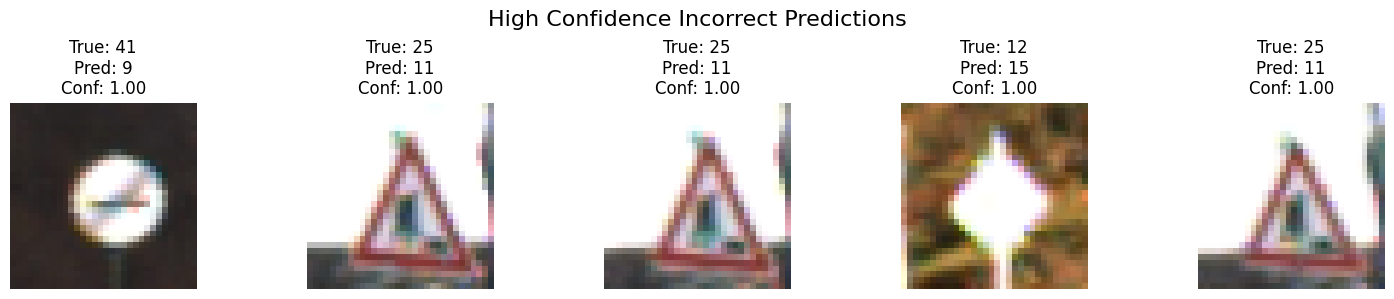

In [22]:
# Visualize samples with highest confidence
def visualize_high_confidence_predictions(X, y_true, y_pred_probs, y_pred, num_samples=5):
    # Get the confidence (max probability) for each prediction
    confidences = np.max(y_pred_probs, axis=1)
    
    # Find correct and incorrect predictions
    correct_mask = y_true == y_pred
    correct_indices = np.where(correct_mask)[0]
    incorrect_indices = np.where(~correct_mask)[0]
    
    # Get highest confidence for both correct and incorrect predictions
    if len(correct_indices) > 0:
        correct_confidences = confidences[correct_indices]
        high_conf_correct = correct_indices[np.argsort(-correct_confidences)[:num_samples]]
    else:
        high_conf_correct = []
        
    if len(incorrect_indices) > 0:
        incorrect_confidences = confidences[incorrect_indices]
        high_conf_incorrect = incorrect_indices[np.argsort(-incorrect_confidences)[:num_samples]]
    else:
        high_conf_incorrect = []
    
    # Plot correct predictions with high confidence
    if len(high_conf_correct) > 0:
        plt.figure(figsize=(15, 3))
        plt.suptitle("High Confidence Correct Predictions", fontsize=16)
        
        for i, idx in enumerate(high_conf_correct):
            if i < num_samples:
                plt.subplot(1, 5, i+1)
                plt.imshow(X[idx])
                plt.title(f"True: {y_true[idx]}\nConf: {confidences[idx]:.2f}")
                plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # Plot incorrect predictions with high confidence
    if len(high_conf_incorrect) > 0:
        plt.figure(figsize=(15, 3))
        plt.suptitle("High Confidence Incorrect Predictions", fontsize=16)
        
        for i, idx in enumerate(high_conf_incorrect):
            if i < num_samples:
                plt.subplot(1, 5, i+1)
                plt.imshow(X[idx])
                plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}\nConf: {confidences[idx]:.2f}")
                plt.axis('off')
        
        plt.tight_layout()
        plt.show()

visualize_high_confidence_predictions(X_test, y_test, y_pred_probs, y_pred)

## 8. Save the Model

In [23]:
# Save the trained model
model_save_path = "../models/road_sign_recognition_model.h5"
model.save_model(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to ../models/road_sign_recognition_model.h5


## 9. Test on Sample Image

In [24]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Assuming preprocess_image and model are defined elsewhere

# Test on a single sample image
def test_on_sample(img_path):
    # Check if the file exists
    if not os.path.exists(img_path):
        print(f"Error: Image file not found at {img_path}")
        return None, None
        
    # Preprocess the image
    try:
        img_array = preprocess_image(img_path)
        
        # Make prediction
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])
        
        # Display the image and prediction
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(6, 6))
            plt.imshow(img)
            plt.title(f"Predicted Class: {predicted_class}\nConfidence: {confidence:.4f}")
            plt.axis('off')
            plt.show()
            
            return predicted_class, confidence
        else:
            print(f"Error: Could not load image at {img_path}")
            return None, None
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None, None

Testing on image: ../data/raw/Test/00000.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


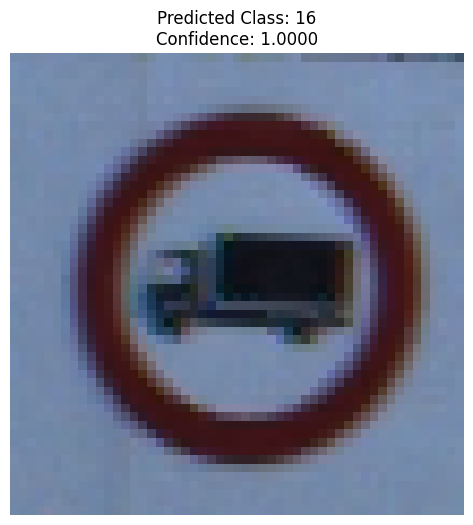

Predicted class: 16, Confidence: 1.0000


In [25]:
# Select a sample from the test directory
sample_test_image = os.path.join(test_images_dir, test_df.iloc[0]['Path'])
print(f"Testing on image: {sample_test_image}")

predicted_class, confidence = test_on_sample(sample_test_image)
print(f"Predicted class: {predicted_class}, Confidence: {confidence:.4f}")

## 10. Conclusion

In this notebook, we:
1. Loaded and explored the GTSRB road sign dataset
2. Preprocessed the data for our CNN model
3. Defined and trained a road sign recognition model
4. Evaluated the model's performance on test data
5. Visualized predictions and analyzed model accuracy
6. Saved the model for future deployment

The model achieved [will be filled with test accuracy] accuracy on the test dataset, demonstrating its ability to recognize road signs effectively.